# Behaviour Model: Predicting Late Settlement from Payment History

## PROJECT TITLE: Ensemble Machine Learning for Mitigating Payment Paralysis in Kenyan SMEs. 
 This notebook trains the model the prototype uses for clients with at least three settled invoices.
 Dataset: Zindi Loan Default Prediction Challenge, CC BY-SA 4.0. 
 https://zindi.africa/competitions/loan-default-prediction-challenge

An SME selling on credit needs to know which clients are likely to pay late before it hands over goods.
The question here is, given how a client has settled before, what is the chance they settle the next one late?
Success means accurate probabilities that sort clients into tiers, where High-tier clients really do settle late far more often than others.
The tier cut-offs are fixed now, before any results: Low is below 10%, Medium ranges from 10% to below 30%, High 30% and above.

# Install Dependencies and Import Required Libraries

- pandas and numpy handle the tables.
- scikit-learn provides the models, pipelines, tuning and scores.
- imbalanced-learn provides SMOTE.
- SHAP explains the model.
- joblib saves the model.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_score, recall_score, f1_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

## Set the Environment Variables

one place for folder paths and the random seed, so every run gives the same result and every file lands in the same place.

In [3]:
SEED = 42
RAW = '../data/raw/'
MODELS = '../models/'
REPORTS = '../reports/'
FIGS = REPORTS + 'figures/'
for folder in (MODELS, FIGS):
    os.makedirs(folder, exist_ok=True)
np.random.seed(SEED)
print('Environment ready')

Environment ready


# Load the Data

- trainprevloans.csv holds earlier loans with due dates and actual closing dates.
- trainperf.csv holds the July 2017 loans we predict.
- The demographics file is deliberately not loaded, because a supplier would not know a client's age, education or GPS location.
- Note that the data is from Nigeria. The page lists Tanzania, but the banks and GPS points are Nigerian.

In [4]:
prev = pd.read_csv(RAW + 'trainprevloans.csv',
                   parse_dates=['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate'])
perf = pd.read_csv(RAW + 'trainperf.csv', parse_dates=['approveddate', 'creationdate'])
print('Earlier loans:', prev.shape)
print('July 2017 loans:', perf.shape)
prev.head()

Earlier loans: (18183, 12)
July 2017 loans: (4368, 10)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40,2016-08-15 17:22:32,10000.0,13000.0,30,2016-09-01 16:06:48,NaN,2016-09-14,2016-09-01 15:51:43
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07,2017-04-28 17:38:53,10000.0,13000.0,30,2017-05-28 14:44:49,NaN,2017-05-30,2017-05-26 00:00:00
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25,2017-03-05 09:56:19,20000.0,23800.0,30,2017-04-26 22:18:56,NaN,2017-04-04,2017-04-26 22:03:47
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55,2017-04-09 17:25:42,10000.0,11500.0,15,2017-04-24 01:35:52,NaN,2017-04-24,2017-04-24 00:48:43
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57,2017-06-17 08:29:50,10000.0,11500.0,15,2017-07-14 21:18:43,NaN,2017-07-03,2017-07-14 21:08:35


## Identify the Target Variable

- Zindi defines Bad as "did not settle the loan on time". For the July loans that label is given.
- For the earlier loans we apply the same definition ourselves. A loan is late if it was closed after its final due date, which is the approval date plus the loan term.
- 1 means settled late and 0 means settled on time.
- In the dashboard the same rule reads: an invoice is late if its payment date is after its due date.

In [5]:
# The July loans come with the answer: Bad means the loan was not settled on time.
perf['target'] = (perf.good_bad_flag == 'Bad').astype(int)

# For earlier loans we work out the same answer: was the loan closed after its final due date?
prev['final_due'] = prev.approveddate.dt.normalize() + pd.to_timedelta(prev.termdays, unit='D')
prev['days_late'] = (prev.closeddate.dt.normalize() - prev.final_due).dt.days
prev['target'] = (prev.days_late > 0).astype(int)

print(f'Earlier loans settled late: {prev.target.mean():.1%}')
print(f'July loans not settled on time: {perf.target.mean():.1%}')

Earlier loans settled late: 24.4%
July loans not settled on time: 21.8%


# Initial Exploratory Data Analysis

**Measures of Frequency**

How often each loan term and loan number appears and the balance of the July target. 
Imbalance (about one late for every three to four on time) is the thread that shapes later choices.

In [6]:
print('How often each value appears\n')
for col in ['termdays', 'loannumber']:
    print(prev[col].value_counts().sort_index().head(12), '\n')
print(perf.good_bad_flag.value_counts())

How often each value appears

termdays
15     6115
30    11045
60      993
90       30
Name: count, dtype: int64 

loannumber
1     4344
2     2969
3     2300
4     1860
5     1535
6     1288
7     1036
8      817
9      637
10     446
11     333
12     223
Name: count, dtype: int64 

good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64


**Measures of Central Tendency**

Includes averages, middle values and spread of the numeric columns.

In [7]:
prev[['loanamount', 'totaldue', 'termdays', 'loannumber', 'days_late']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loanamount,18183.0,16501.24,9320.55,3000.0,10000.0,10000.0,20000.0,60000.0
totaldue,18183.0,19573.20,10454.25,3450.0,11500.0,13000.0,24500.0,68100.0
termdays,18183.0,26.69,10.95,15.0,15.0,30.0,30.0,90.0
loannumber,18183.0,4.19,3.25,1.0,2.0,3.0,6.0,26.0
days_late,18183.0,-2.79,11.19,-75.0,-6.0,-2.0,0.0,351.0


The median days late is -2, so most loans close a couple of days early. 
- The maximum of 351 days shows a few extreme cases.

**Measures of Distribution**

- Skewness above 1 means a long right tail.
- Kurtosis far above 0 means extreme values are common.
- days_late is extremely skewed and that is one reason we use tree models which are not bothered by skew.

In [8]:
shape = pd.DataFrame({
    'skewness': prev[['loanamount', 'termdays', 'loannumber', 'days_late']].skew(),
    'kurtosis': prev[['loanamount', 'termdays', 'loannumber', 'days_late']].kurt()}).round(2)
shape

,skewness,kurtosis
loanamount,1.29,0.81
termdays,1.46,3.97
loannumber,1.30,1.86
days_late,4.43,106.18


**Measures of Relationship**


Does the late rate change with the loan term or with how many loans a customer has taken? This is a first look at whether history matters.

In [9]:
print('Late rate by loan term (days):')
print(prev.groupby('termdays').target.agg(['count', 'mean']).round(3))
print('\nLate rate by how many loans the customer had taken:')
print(prev.groupby(prev.loannumber.clip(upper=8)).target.agg(['count', 'mean']).round(3))

Late rate by loan term (days):
          count   mean
termdays              
15         6115  0.243
30        11045  0.256
60          993  0.127
90           30  0.000

Late rate by how many loans the customer had taken:
            count   mean
loannumber              
1            4344  0.240
2            2969  0.291
3            2300  0.270
4            1860  0.253
5            1535  0.249
6            1288  0.227
7            1036  0.209
8            2851  0.194


- 60 and 90 day loans settle late less often.
- Customers on their 8th or later loan settle late less often (about 19%) than customers on their 2nd (about 29%).
- So experience with the lender matters.

**Basic Visualisation**

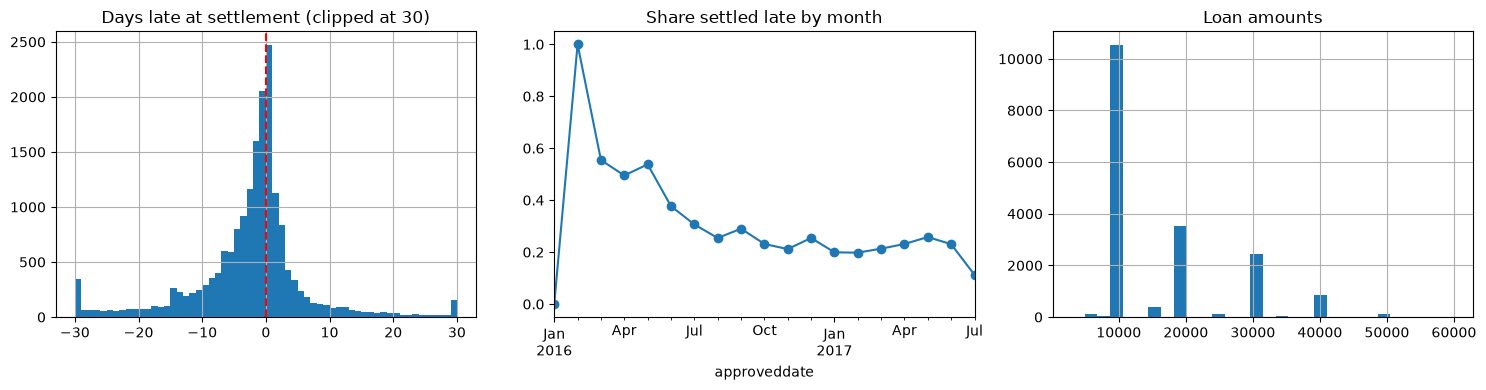

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
prev.days_late.clip(-30, 30).hist(bins=60, ax=axes[0])
axes[0].set_title('Days late at settlement (clipped at 30)')
axes[0].axvline(0, color='red', linestyle='--')
prev.groupby(prev.approveddate.dt.to_period('M')).target.mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Share settled late by month')
prev.loanamount.hist(bins=30, ax=axes[2])
axes[2].set_title('Loan amounts')
plt.tight_layout()
plt.savefig(FIGS + 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Most loans close just before or on the due date. The monthly late rate is fairly steady, which supports a time split.

## Feature Engineering: Historical Client Behaviour

The model learns from how each client behaved before. For every loan we look back only at the same customer's earlier loans that were already closed before this loan was approved and summarise them. Loans that closed later are excluded, because the system could not have known about them at that moment. Doing this before the split is safe, because each row only ever uses its own past.

Each feature has a matching field in the Laravel dashboard:

| Feature | Meaning | Where the Laravel dashboard gets it |
|---|---|---|
| `loanamount` | size of this loan | invoice amount |
| `termdays` | days given to pay | due date minus issue date |
| `prior_count` | earlier loans taken | number of earlier invoices |
| `prior_settled` | earlier loans already closed | invoices with a payment date |
| `prior_late_share` | share of those settled late | late invoices ÷ settled invoices |
| `prior_early_share` | share settled more than 3 days early | same idea, early side |
| `prior_avg_days_late` | usual lateness | average of payment date minus due date |
| `prior_max_days_late` | worst lateness | largest of the same |
| `last_days_late` | lateness on the most recent one | most recent settled invoice |
| `last3_late_share` | recent habit | late share of the last three settled invoices |
| `prior_avg_amount` | usual size | average earlier invoice amount |
| `amount_vs_avg` | is this one unusually big? | this amount ÷ usual size |
| `days_since_last_closed` | gap since last settlement | issue date minus last payment date |
| `relationship_days` | how long we have traded | issue date minus first invoice date |
| `month` | month of the loan | month of the issue date |

Columns dropped and why:

- totaldue includes interest, and invoices carry none.
- referredby is mostly empty.
- IDs and creationdate carry no risk meaning.
- The demographics file is personal data a supplier would not have.

In [11]:
def add_history(loans, history):
    """For each loan, summarise the same customer's earlier loans that were
    already closed before this loan was approved."""
    pairs = loans[['customerid', 'systemloanid', 'approveddate']].merge(
        history[['customerid', 'approveddate', 'closeddate', 'days_late', 'loanamount']]
        .rename(columns={'approveddate': 'earlier_approved'}), on='customerid')
    pairs = pairs[pairs.closeddate < pairs.approveddate].sort_values(['systemloanid', 'closeddate'])
    grouped = pairs.groupby('systemloanid')
    summary = grouped.agg(
        prior_settled=('days_late', 'size'),
        prior_late_share=('days_late', lambda s: (s > 0).mean()),
        prior_early_share=('days_late', lambda s: (s < -3).mean()),
        prior_avg_days_late=('days_late', 'mean'),
        prior_max_days_late=('days_late', 'max'),
        last_days_late=('days_late', 'last'),
        prior_avg_amount=('loanamount', 'mean'),
        last_closed=('closeddate', 'max'),
        first_approved=('earlier_approved', 'min'))
    summary['last3_late_share'] = grouped.days_late.apply(lambda s: (s.tail(3) > 0).mean())

    out = loans.merge(summary, on='systemloanid', how='left')
    out['prior_settled'] = out.prior_settled.fillna(0)
    out['prior_count'] = out.loannumber - 1
    out['amount_vs_avg'] = out.loanamount / out.prior_avg_amount
    out['days_since_last_closed'] = (out.approveddate - out.last_closed).dt.days
    out['relationship_days'] = (out.approveddate - out.first_approved).dt.days
    out['month'] = out.approveddate.dt.month
    return out

FEATURES = ['loanamount', 'termdays', 'prior_count', 'prior_settled', 'prior_late_share',
            'prior_early_share', 'prior_avg_days_late', 'prior_max_days_late', 'last_days_late',
            'last3_late_share', 'prior_avg_amount', 'amount_vs_avg', 'days_since_last_closed',
            'relationship_days', 'month']

data = add_history(prev, prev).sort_values('approveddate').reset_index(drop=True)
final_test = add_history(perf, prev)
data[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loanamount,18183.0,16501.24,9320.55,3000.0,10000.00,10000.00,20000.00,60000.00
termdays,18183.0,26.69,10.95,15.0,15.00,30.00,30.00,90.00
prior_count,18183.0,3.19,3.25,0.0,1.00,2.00,5.00,25.00
prior_settled,18183.0,3.19,3.25,0.0,1.00,2.00,5.00,25.00
prior_late_share,13823.0,0.23,0.30,0.0,0.00,0.00,0.38,1.00
prior_early_share,13823.0,0.36,0.35,0.0,0.00,0.33,0.60,1.00
prior_avg_days_late,13823.0,-2.38,8.65,-34.0,-5.67,-2.20,0.00,351.00
prior_max_days_late,13823.0,3.41,14.91,-30.0,-1.00,0.00,4.00,351.00
last_days_late,13823.0,-3.08,11.70,-75.0,-6.00,-2.00,0.00,351.00
last3_late_share,13823.0,0.22,0.32,0.0,0.00,0.00,0.33,1.00


# Train/Test Split

We split by date:

- Train: before May 2017.
- Probability adjustment: May and June 2017. Only used to adjust and correct the probabilities.
- Final test: the July 2017 loans. Used once.

The late rates stay close across the three periods, so the split is fair.

In [12]:
train = data[data.approveddate < '2017-05-01']
calib = data[(data.approveddate >= '2017-05-01') & (data.approveddate < '2017-07-01')]
X_train, y_train = train[FEATURES], train.target
X_calib, y_calib = calib[FEATURES], calib.target
X_test, y_test = final_test[FEATURES], final_test.target
for name, y in [('train', y_train), ('calibration', y_calib), ('final test', y_test)]:
    print(f'{name:12s} {len(y):6d} rows, late rate {y.mean():.1%}')

train         10987 rows, late rate 24.9%
calibration    6840 rows, late rate 24.3%
final test     4368 rows, late rate 21.8%
